In [1]:
!pip install fastf1
!pip install xgboost
!pip install streamlit
!pip install pyngrok
!pip install plotly
!pip install shap
!pip install streamlit-autorefresh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 700.8/700.8 kB 11.7 MB/s eta 0:00:00


In [2]:
import fastf1
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import joblib
import shap

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [3]:
import os
CACHE_DIR = "./cache"
os.makedirs(CACHE_DIR, exist_ok=True)
fastf1.Cache.enable_cache(CACHE_DIR)

In [4]:
session = fastf1.get_session(2023, 'Bahrain', 'R')

session.load(laps=True)

laps = session.laps

laps.head()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_d

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:04:15.902000,VER,1,0 days 00:01:39.019000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.414000,...,False,Red Bull Racing,0 days 01:02:36.652000,2023-03-05 15:03:38.501,12,1.0,False,,False,False
1,0 days 01:05:53.876000,VER,1,0 days 00:01:37.974000,2.0,1.0,NaT,NaT,0 days 00:00:31.342000,0 days 00:00:42.504000,...,False,Red Bull Racing,0 days 01:04:15.902000,2023-03-05 15:05:17.751,12,1.0,False,,False,True
2,0 days 01:07:31.882000,VER,1,0 days 00:01:38.006000,3.0,1.0,NaT,NaT,0 days 00:00:31.388000,0 days 00:00:42.469000,...,False,Red Bull Racing,0 days 01:05:53.876000,2023-03-05 15:06:55.725,1,1.0,False,,False,True
3,0 days 01:09:09.858000,VER,1,0 days 00:01:37.976000,4.0,1.0,NaT,NaT,0 days 00:00:31.271000,0 days 00:00:42.642000,...,False,Red Bull Racing,0 days 01:07:31.882000,2023-03-05 15:08:33.731,1,1.0,False,,False,True
4,0 days 01:10:47.893000,VER,1,0 days 00:01:38.035000,5.0,1.0,NaT,NaT,0 days 00:00:31.244000,0 days 00:00:42.724000,...,False,Red Bull Racing,0 days 01:09:09.858000,2023-03-05 15:10:11.707,1,1.0,False,,False,True


In [5]:
df = laps.copy()

# Remove missing lap times
df = df.dropna(subset=['LapTime'])

# Convert lap times
df['LapTimeSeconds'] = df['LapTime'].dt.total_seconds()

# Encode compounds
compound_map = {
    'SOFT': 0,
    'MEDIUM': 1,
    'HARD': 2,
    'INTERMEDIATE': 3,
    'WET': 4
}

df['CompoundEncoded'] = df['Compound'].map(compound_map)

# Future position
df['NextPosition'] = (
    df.groupby('Driver')['Position']
    .shift(-1)
)

# Target variable
df['FutureOvertake'] = (
    df['NextPosition'] < df['Position']
).astype(int)

# Rolling average pace
df['AvgPace3'] = (
    df.groupby('Driver')['LapTimeSeconds']
    .rolling(3)
    .mean()
    .reset_index(0, drop=True)
)

# Position trend
df['PositionTrend'] = (
    df.groupby('Driver')['Position']
    .diff()
)

# Lap delta
df['LapDelta'] = (
    df.groupby('Driver')['LapTimeSeconds']
    .diff()
)

# Tyre advantage
df['TyreAdvantage'] = (
    df['TyreLife']
    - df.groupby('LapNumber')['TyreLife'].transform('mean')
)

# Pace
df['Pace'] = 1 / df['LapTimeSeconds']

# Fill NaNs
df = df.fillna(0)

df.head()

/tmp/ipykernel_2643/1098128313.py:61: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(0)


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,IsAccurate,LapTimeSeconds,CompoundEncoded,NextPosition,FutureOvertake,AvgPace3,PositionTrend,LapDelta,TyreAdvantage,Pace
0,0 days 01:04:15.902000,VER,1,0 days 00:01:39.019000,1.0,1.0,0,0,0,0 days 00:00:42.414000,...,False,99.019,0,1.0,0,0.000000,0.0,0.000,1.65,0.010099
1,0 days 01:05:53.876000,VER,1,0 days 00:01:37.974000,2.0,1.0,0,0,0 days 00:00:31.342000,0 days 00:00:42.504000,...,True,97.974,0,1.0,0,0.000000,0.0,-1.045,1.65,0.010207
2,0 days 01:07:31.882000,VER,1,0 days 00:01:38.006000,3.0,1.0,0,0,0 days 00:00:31.388000,0 days 00:00:42.469000,...,True,98.006,0,1.0,0,98.333000,0.0,0.032,1.65,0.010203
3,0 days 01:09:09.858000,VER,1,0 days 00:01:37.976000,4.0,1.0,0,0,0 days 00:00:31.271000,0 days 00:00:42.642000,...,True,97.976,0,1.0,0,97.985333,0.0,-0.030,1.65,0.010207
4,0 days 01:10:47.893000,VER,1,0 days 00:01:38.035000,5.0,1.0,0,0,0 days 00:00:31.244000,0 days 00:00:42.724000,...,True,98.035,0,1.0,0,98.005667,0.0,0.059,1.65,0.010200


In [6]:
features = [
    'LapNumber',
    'Position',
    'TyreLife',
    'CompoundEncoded',
    'LapTimeSeconds',
    'AvgPace3',
    'PositionTrend',
    'LapDelta',
    'TyreAdvantage',
    'Pace'
]

X = df[features]

y = df['FutureOvertake']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [9]:
preds = model.predict(X_test)

acc = accuracy_score(y_test, preds)

print("Accuracy:", acc)

print(classification_report(y_test, preds))

Accuracy: 0.8862559241706162
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       182
           1       0.60      0.52      0.56        29

    accuracy                           0.89       211
   macro avg       0.76      0.73      0.75       211
weighted avg       0.88      0.89      0.88       211



In [10]:
probs = model.predict_proba(X_test)[:,1]

print(probs[:10])

[0.00244355 0.00098329 0.2834911  0.00090318 0.04807211 0.01169949
 0.02418046 0.15038976 0.08589712 0.58825374]


In [11]:
joblib.dump(model, 'f1_overtake_model.pkl')

['f1_overtake_model.pkl']

In [12]:
live_df = df.copy()

live_probs = model.predict_proba(
    live_df[features]
)[:,1]

live_df['OvertakeProbability'] = live_probs * 100

latest = (
    live_df.sort_values('LapNumber')
    .groupby('Driver')
    .tail(1)
)

latest[
    [
        'Driver',
        'Position',
        'Compound',
        'TyreLife',
        'OvertakeProbability'
    ]
].sort_values(
    'OvertakeProbability',
    ascending=False
)

,Driver,Position,Compound,TyreLife,OvertakeProbability
266,LEC,3.0,HARD,6.0,8.487179
380,SAR,12.0,SOFT,16.0,8.217287
436,MAG,13.0,SOFT,16.0,6.138336
492,DEV,14.0,HARD,29.0,4.689412
759,OCO,17.0,HARD,9.0,4.641929
718,HUL,15.0,SOFT,19.0,3.459603
814,NOR,17.0,SOFT,7.0,2.270016
113,GAS,9.0,SOFT,17.0,2.109468
662,ZHO,16.0,SOFT,5.0,1.606273
606,ALB,10.0,SOFT,17.0,1.210831


In [13]:
fig = px.bar(
    latest.sort_values(
        'OvertakeProbability',
        ascending=False
    ),
    x='Driver',
    y='OvertakeProbability',
    title='Live Overtake Probability'
)

fig.show()

In [16]:
driver = 'HAM'
lap = session.laps.pick_drivers(driver).pick_fastest()

telemetry = lap.get_car_data().add_distance()

fig = px.line(
    telemetry,
    x='Distance',
    y='Speed',
    title=f'{driver} Speed Trace'
)

fig.show()

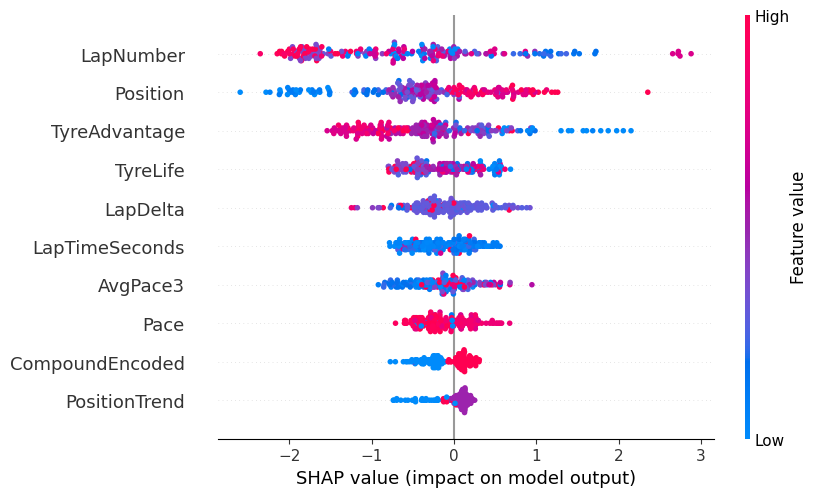

In [18]:
explainer = shap.Explainer(model)

shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

In [19]:
%%writefile app.py
import streamlit as st
st.title("F1 Race Analytics")

Writing app.py


In [20]:
from pyngrok import ngrok

In [21]:
!streamlit run app.py &>/dev/null&

In [22]:
from pyngrok import ngrok
# Replace 'YOUR_AUTH_TOKEN' with your actual ngrok authtoken
# You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token('3EqUDF8y2aXSGXvmZKjmJb3j6sn_5THdG1JBZL45SGBbVR5JZ')

public_url = ngrok.connect('8501')
public_url

<NgrokTunnel: "https://fetch-privatize-truck.ngrok-free.dev" -> "http://localhost:8501">

In [23]:
%%writefile app.py


import streamlit as st
import fastf1
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import joblib
import os

# =====================================================
# PAGE CONFIG
# =====================================================

st.set_page_config(
    page_title="F1 Race Analytics",
    page_icon="🏎️",
    layout="wide"
)

st.markdown("""
<style>
html, body, [class*="css"]  { background-color: #0a0a0a; color: white; }
.stApp { background-color: #0a0a0a; }
h1, h2, h3, h4 { color: #ff1e00; font-family: sans-serif; }
section[data-testid="stSidebar"] {
    background-color: #111111;
    border-right: 2px solid #ff1e00;
}
div[data-testid="metric-container"] {
    background-color: #151515;
    border: 2px solid #ff1e00;
    padding: 20px;
    border-radius: 15px;
}
.stDataFrame { border: 1px solid #ff1e00; }
</style>
""", unsafe_allow_html=True)

st.markdown("<h1 style='text-align:center;'>🏎️ F1 RACE ANALYTICS</h1>", unsafe_allow_html=True)
st.markdown("---")

# =====================================================
# FASTF1 CACHE
# =====================================================

os.makedirs("cache", exist_ok=True)
fastf1.Cache.enable_cache("cache")

# =====================================================
# HELPER — plain feature engineering (no st.cache_data,
# called only after a fresh session load)
# =====================================================

def engineer_features(laps):
    df = laps.copy().reset_index(drop=True)
    df = df.dropna(subset=["LapTime"])
    df["LapTimeSeconds"] = df["LapTime"].dt.total_seconds()

    compound_map = {"SOFT": 0, "MEDIUM": 1, "HARD": 2, "INTERMEDIATE": 3, "WET": 4}
    df["CompoundEncoded"] = df["Compound"].map(compound_map)

    df["NextPosition"] = df.groupby("Driver")["Position"].shift(-1)
    df["FutureOvertake"] = (df["NextPosition"] < df["Position"]).astype(int)
    df["AvgPace3"] = (
        df.groupby("Driver")["LapTimeSeconds"]
        .rolling(3).mean().reset_index(0, drop=True)
    )
    df["PositionTrend"] = df.groupby("Driver")["Position"].diff()
    df["LapDelta"]       = df.groupby("Driver")["LapTimeSeconds"].diff()
    df["TyreAdvantage"]  = (
        df["TyreLife"] - df.groupby("LapNumber")["TyreLife"].transform("mean")
    )
    df["Pace"]    = 1 / df["LapTimeSeconds"]
    df["Sector1"] = df["Sector1Time"].dt.total_seconds()
    df["Sector2"] = df["Sector2Time"].dt.total_seconds()
    df["Sector3"] = df["Sector3Time"].dt.total_seconds()
    return df.fillna(0)


# =====================================================
# LOAD MODEL (cached — model never changes)
# =====================================================
# =====================================================
# LOAD MODEL
# =====================================================

import os
import joblib

MODEL_PATH = "f1_overtake_model.pkl"

@st.cache_resource
def load_model():
    st.write("Files in directory:", os.listdir("."))

    if os.path.exists(MODEL_PATH):
        return joblib.load(MODEL_PATH)
    else:
        st.error(f"Model file not found: {MODEL_PATH}")
        return None

try:
    model = load_model()
    model_loaded = model is not None
except Exception as e:
    model_loaded = False
    st.error(f"Error loading model: {e}")

# =====================================================
# RACE CALENDAR  (cached by year — pure/serialisable)
# =====================================================

@st.cache_data(show_spinner=False)
def get_event_schedule(year):
    schedule = fastf1.get_event_schedule(year, include_testing=False)
    schedule = schedule[schedule["EventFormat"] != "testing"]
    return schedule[["EventName", "RoundNumber"]].dropna()

# =====================================================
# SIDEBAR
# =====================================================

st.sidebar.title("⚙️ Race Settings")

year = st.sidebar.selectbox("Season", list(range(2018, 2027)), index=5)

with st.spinner("Fetching race calendar..."):
    try:
        schedule_df = get_event_schedule(year)
        race_names = schedule_df["EventName"].tolist()
    except Exception as e:
        st.sidebar.error(f"Could not load calendar: {e}")
        race_names = ["Bahrain"]

race = st.sidebar.selectbox("Grand Prix", race_names)

# =====================================================
# SESSION LOADING — keyed by (year, race) in session_state
# This is the critical fix: we store the session object in
# st.session_state so Streamlit never tries to hash it,
# and we reload only when year or race actually changes.
# =====================================================

session_key = f"{year}_{race}"

if st.session_state.get("session_key") != session_key:
    # Selection changed — load fresh data
    with st.spinner(f"Loading {year} {race} race data… (first load may take a minute)"):
        try:
            session = fastf1.get_session(year, race, "R")
            session.load(laps=True, telemetry=True, weather=True, messages=False)
            df = engineer_features(session.laps)

            st.session_state["session_key"] = session_key
            st.session_state["session"]     = session
            st.session_state["df"]          = df
        except Exception as e:
            st.error(f"❌ Could not load session: {e}")
            st.stop()
else:
    # Same race — reuse what's already in memory
    session = st.session_state["session"]
    df      = st.session_state["df"]

# =====================================================
# DYNAMIC DRIVER LIST
# =====================================================

all_drivers = sorted(df["Driver"].dropna().unique().tolist())

st.sidebar.markdown("---")
driver_choice = st.sidebar.selectbox("Telemetry Driver", all_drivers, index=0)

# =====================================================
# TELEMETRY HELPERS  (keyed by race + driver — never hash session)
# =====================================================

def get_telemetry_one(driver):
    """Load & cache single-driver telemetry in session_state."""
    key = f"tel_{session_key}_{driver}"
    if key not in st.session_state:
        lap = session.laps.pick_driver(driver).pick_fastest()
        st.session_state[key] = lap.get_car_data().add_distance()
    return st.session_state[key]

def get_telemetry_two(d1, d2):
    """Load & cache two-driver telemetry in session_state."""
    key = f"tel2_{session_key}_{d1}_{d2}"
    if key not in st.session_state:
        lap1 = session.laps.pick_driver(d1).pick_fastest()
        tel1 = lap1.get_car_data().add_distance()
        lap2 = session.laps.pick_driver(d2).pick_fastest()
        tel2 = lap2.get_car_data().add_distance()
        st.session_state[key] = (tel1, tel2)
    return st.session_state[key]

# =====================================================
# FEATURES & PREDICTIONS
# =====================================================

features = [
    "LapNumber", "Position", "TyreLife", "CompoundEncoded",
    "LapTimeSeconds", "AvgPace3", "PositionTrend",
    "LapDelta", "TyreAdvantage", "Pace"
]

if model_loaded:
    df["OvertakeProbability"] = model.predict_proba(df[features])[:, 1] * 100
else:
    df["OvertakeProbability"] = np.nan

latest = df.sort_values("LapNumber").groupby("Driver").tail(1)

# =====================================================
# TOP METRICS
# =====================================================

col1, col2, col3, col4 = st.columns(4)
leader       = latest.sort_values("Position").iloc[0]["Driver"]
highest_prob = round(latest["OvertakeProbability"].max(), 2) if model_loaded else "N/A"
avg_prob     = round(latest["OvertakeProbability"].mean(), 2) if model_loaded else "N/A"
current_lap  = int(latest["LapNumber"].max())

with col1: st.metric("🏁 Race Leader",       leader)
with col2: st.metric("🔥 Highest Overtake %", highest_prob)
with col3: st.metric("📊 Avg Probability",    avg_prob)
with col4: st.metric("🛞 Current Lap",        current_lap)

st.markdown("---")

# =====================================================
# LIVE TABLE
# =====================================================

st.subheader("📊 LIVE OVERTAKE PROBABILITIES")
table = (
    latest[["Driver", "Position", "Compound", "TyreLife", "OvertakeProbability"]]
    .sort_values("OvertakeProbability", ascending=False)
)
st.dataframe(table, use_container_width=True)

# =====================================================
# BAR CHART
# =====================================================

if model_loaded:
    st.subheader("🔥 OVERTAKE INTENSITY")
    bar_fig = px.bar(
        table, x="Driver", y="OvertakeProbability",
        color="OvertakeProbability", template="plotly_dark", text_auto=".2f"
    )
    bar_fig.update_layout(paper_bgcolor="#0a0a0a", plot_bgcolor="#0a0a0a", font_color="white")
    st.plotly_chart(bar_fig, use_container_width=True)

# =====================================================
# POSITION CHANGES
# =====================================================

st.subheader("📈 DRIVER POSITION CHANGES")
pos_fig = px.line(df, x="LapNumber", y="Position", color="Driver", template="plotly_dark")
pos_fig.update_yaxes(autorange="reversed")
pos_fig.update_layout(paper_bgcolor="#0a0a0a", plot_bgcolor="#0a0a0a", font_color="white")
st.plotly_chart(pos_fig, use_container_width=True)

# =====================================================
# TYRE DEGRADATION
# =====================================================

st.subheader("🛞 TYRE DEGRADATION ANALYSIS")
tyre_fig = px.scatter(
    df, x="TyreLife", y="LapTimeSeconds", color="Compound",
    template="plotly_dark", hover_data=["Driver"]
)
tyre_fig.update_layout(paper_bgcolor="#0a0a0a", plot_bgcolor="#0a0a0a", font_color="white")
st.plotly_chart(tyre_fig, use_container_width=True)

# =====================================================
# PIT STOP STRATEGY
# =====================================================

st.subheader("🛞 PIT STOP STRATEGY")
pit_data = (
    df.groupby(["Driver", "Stint"])
    .agg({"LapNumber": "min", "Compound": "first"})
    .reset_index()
)
pit_fig = px.scatter(
    pit_data, x="LapNumber", y="Driver", color="Compound",
    template="plotly_dark", title="Pit Stop Timeline"
)
pit_fig.update_layout(paper_bgcolor="#0a0a0a", plot_bgcolor="#0a0a0a", font_color="white")
st.plotly_chart(pit_fig, use_container_width=True)

# =====================================================
# SECTOR PERFORMANCE
# =====================================================

st.subheader("⚡ SECTOR PERFORMANCE")
sector_avg = df.groupby("Driver")[["Sector1", "Sector2", "Sector3"]].mean().reset_index()
sec_fig = go.Figure()
for s in ["Sector1", "Sector2", "Sector3"]:
    sec_fig.add_trace(go.Bar(x=sector_avg["Driver"], y=sector_avg[s], name=s))
sec_fig.update_layout(
    barmode="group", template="plotly_dark",
    paper_bgcolor="#0a0a0a", plot_bgcolor="#0a0a0a",
    font_color="white", title="Average Sector Performance"
)
st.plotly_chart(sec_fig, use_container_width=True)

# =====================================================
# FASTEST LAPS
# =====================================================

st.subheader("⚡ FASTEST LAPS")
fastest = df.groupby("Driver")["LapTimeSeconds"].min().reset_index().sort_values("LapTimeSeconds")
fast_fig = px.bar(fastest, x="Driver", y="LapTimeSeconds", color="LapTimeSeconds", template="plotly_dark")
fast_fig.update_layout(paper_bgcolor="#0a0a0a", plot_bgcolor="#0a0a0a", font_color="white")
st.plotly_chart(fast_fig, use_container_width=True)

# =====================================================
# SINGLE DRIVER TELEMETRY
# =====================================================

st.subheader(f"🏎️ FASTEST LAP TELEMETRY — {driver_choice}")
with st.spinner(f"Loading telemetry for {driver_choice}…"):
    try:
        telemetry = get_telemetry_one(driver_choice)
        tele_fig = go.Figure()
        tele_fig.add_trace(go.Scatter(
            x=telemetry["Distance"], y=telemetry["Speed"],
            mode="lines", name="Speed", line=dict(color="#ff1e00")
        ))
        tele_fig.update_layout(
            template="plotly_dark", paper_bgcolor="#0a0a0a",
            plot_bgcolor="#0a0a0a", font_color="white",
            title=f"{driver_choice} — Fastest Lap Speed Trace",
            xaxis_title="Distance (m)", yaxis_title="Speed (km/h)"
        )
        st.plotly_chart(tele_fig, use_container_width=True)
    except Exception as e:
        st.error(f"Telemetry unavailable for {driver_choice}: {e}")

st.markdown("---")

# =====================================================
# DRIVER vs DRIVER — FULL RACE COMPARISON
# =====================================================

st.subheader("⚔️ DRIVER vs DRIVER — FULL RACE COMPARISON")

cmp1, cmp2 = st.columns(2)
with cmp1:
    driver1 = st.selectbox("Select Driver 1", all_drivers, index=0, key="d1")
with cmp2:
    driver2 = st.selectbox("Select Driver 2", all_drivers, index=min(1, len(all_drivers)-1), key="d2")

if driver1 == driver2:
    st.warning("Please select two different drivers.")
else:
    d1_df = df[df["Driver"] == driver1]
    d2_df = df[df["Driver"] == driver2]

    # Lap times
    st.markdown("#### 📉 Lap Time Battle")
    lt_fig = go.Figure()
    lt_fig.add_trace(go.Scatter(x=d1_df["LapNumber"], y=d1_df["LapTimeSeconds"],
        mode="lines+markers", name=driver1, line=dict(color="#ff1e00")))
    lt_fig.add_trace(go.Scatter(x=d2_df["LapNumber"], y=d2_df["LapTimeSeconds"],
        mode="lines+markers", name=driver2, line=dict(color="#00d2ff")))
    lt_fig.update_layout(template="plotly_dark", paper_bgcolor="#0a0a0a",
        plot_bgcolor="#0a0a0a", font_color="white",
        title=f"{driver1} vs {driver2} — Lap Times",
        xaxis_title="Lap Number", yaxis_title="Lap Time (s)")
    st.plotly_chart(lt_fig, use_container_width=True)

    # Position battle
    st.markdown("#### 🏁 Position Battle")
    pf = go.Figure()
    pf.add_trace(go.Scatter(x=d1_df["LapNumber"], y=d1_df["Position"],
        mode="lines+markers", name=driver1, line=dict(color="#ff1e00")))
    pf.add_trace(go.Scatter(x=d2_df["LapNumber"], y=d2_df["Position"],
        mode="lines+markers", name=driver2, line=dict(color="#00d2ff")))
    pf.update_yaxes(autorange="reversed")
    pf.update_layout(template="plotly_dark", paper_bgcolor="#0a0a0a",
        plot_bgcolor="#0a0a0a", font_color="white",
        title=f"{driver1} vs {driver2} — Race Position",
        xaxis_title="Lap Number", yaxis_title="Position")
    st.plotly_chart(pf, use_container_width=True)

    # Tyre strategy
    st.markdown("#### 🛞 Tyre Strategy")
    COMPOUND_COLORS = {
        "SOFT": "#e8002d", "MEDIUM": "#ffd700", "HARD": "#f0f0f0",
        "INTERMEDIATE": "#39b54a", "WET": "#0067ff"
    }
    sc1, sc2 = st.columns(2)
    for col, drv, drv_df in [(sc1, driver1, d1_df), (sc2, driver2, d2_df)]:
        stints = (
            drv_df.groupby("Stint")
            .agg(LapStart=("LapNumber","min"), LapEnd=("LapNumber","max"), Compound=("Compound","first"))
            .reset_index()
        )
        sf = go.Figure()
        for _, row in stints.iterrows():
            color = COMPOUND_COLORS.get(row["Compound"], "#888888")
            sf.add_trace(go.Bar(
                x=[row["LapEnd"] - row["LapStart"] + 1], y=[drv],
                base=[row["LapStart"] - 1], orientation="h",
                marker_color=color, name=row["Compound"],
                text=f"{row['Compound']} Laps {int(row['LapStart'])}–{int(row['LapEnd'])}",
                hovertemplate="%{text}<extra></extra>"
            ))
        sf.update_layout(template="plotly_dark", paper_bgcolor="#0a0a0a",
            plot_bgcolor="#0a0a0a", font_color="white",
            title=f"{drv} Tyre Strategy", xaxis_title="Lap Number",
            barmode="stack", height=200, showlegend=False)
        with col:
            st.plotly_chart(sf, use_container_width=True)

    # Sector times
    st.markdown("#### ⚡ Average Sector Times")
    sec_cmp = go.Figure()
    for drv, drv_df, color in [(driver1, d1_df, "#ff1e00"), (driver2, d2_df, "#00d2ff")]:
        sec_cmp.add_trace(go.Bar(
            x=["Sector 1", "Sector 2", "Sector 3"],
            y=[drv_df["Sector1"].replace(0, np.nan).mean(),
               drv_df["Sector2"].replace(0, np.nan).mean(),
               drv_df["Sector3"].replace(0, np.nan).mean()],
            name=drv, marker_color=color
        ))
    sec_cmp.update_layout(barmode="group", template="plotly_dark",
        paper_bgcolor="#0a0a0a", plot_bgcolor="#0a0a0a", font_color="white",
        title=f"{driver1} vs {driver2} — Avg Sector Times (s)", yaxis_title="Time (s)")
    st.plotly_chart(sec_cmp, use_container_width=True)

    # Telemetry overlay
    st.markdown("#### 🏎️ Fastest Lap Speed Trace Overlay")
    with st.spinner("Loading comparison telemetry…"):
        try:
            tel1, tel2 = get_telemetry_two(driver1, driver2)
            ov = go.Figure()
            ov.add_trace(go.Scatter(x=tel1["Distance"], y=tel1["Speed"],
                mode="lines", name=driver1, line=dict(color="#ff1e00")))
            ov.add_trace(go.Scatter(x=tel2["Distance"], y=tel2["Speed"],
                mode="lines", name=driver2, line=dict(color="#00d2ff")))
            ov.update_layout(template="plotly_dark", paper_bgcolor="#0a0a0a",
                plot_bgcolor="#0a0a0a", font_color="white",
                title=f"{driver1} vs {driver2} — Fastest Lap Speed Trace",
                xaxis_title="Distance (m)", yaxis_title="Speed (km/h)")
            st.plotly_chart(ov, use_container_width=True)
        except Exception as e:
            st.error(f"Telemetry overlay unavailable: {e}")

    # Head-to-head summary cards
    st.markdown("#### 📋 Head-to-Head Race Summary")
    hc1, hc2 = st.columns(2)
    for col, drv, drv_df, color in [
        (hc1, driver1, d1_df, "#ff1e00"),
        (hc2, driver2, d2_df, "#00d2ff")
    ]:
        last = drv_df.sort_values("LapNumber").iloc[-1]
        best = drv_df["LapTimeSeconds"].replace(0, np.nan).min()
        avg  = drv_df["LapTimeSeconds"].replace(0, np.nan).mean()
        gained = int(drv_df.sort_values("LapNumber").iloc[0]["Position"] - last["Position"])
        compounds = ", ".join(drv_df["Compound"].dropna().unique())
        with col:
            st.markdown(f"""
            <div style="background:#151515;padding:16px;border-radius:12px;border-left:5px solid {color};">
            <h3 style="color:white;">{drv}</h3>
            <p style="color:#ccc;">Finish Position: <b>{int(last['Position'])}</b></p>
            <p style="color:#ccc;">Best Lap: <b>{round(best,3) if not np.isnan(best) else 'N/A'}s</b></p>
            <p style="color:#ccc;">Avg Lap: <b>{round(avg,3) if not np.isnan(avg) else 'N/A'}s</b></p>
            <p style="color:#ccc;">Positions Gained: <b>{gained:+d}</b></p>
            <p style="color:#ccc;">Compounds: <b>{compounds}</b></p>
            </div>""", unsafe_allow_html=True)

st.markdown("---")

# =====================================================
# TRACK CONDITIONS
# =====================================================

st.subheader("🌦️ TRACK CONDITIONS")
try:
    weather = session.weather_data
    wf = go.Figure()
    wf.add_trace(go.Scatter(x=weather["Time"], y=weather["AirTemp"],   mode="lines", name="Air Temp"))
    wf.add_trace(go.Scatter(x=weather["Time"], y=weather["TrackTemp"], mode="lines", name="Track Temp"))
    wf.update_layout(template="plotly_dark", paper_bgcolor="#0a0a0a",
        plot_bgcolor="#0a0a0a", font_color="white", title="Track Temperature Analysis")
    st.plotly_chart(wf, use_container_width=True)
except Exception:
    st.info("Weather data not available for this session.")

# =====================================================
# AI RACE INSIGHTS
# =====================================================

if model_loaded:
    st.subheader("🤖 AI RACE INSIGHTS")
    top    = latest.sort_values("OvertakeProbability", ascending=False).iloc[0]
    bottom = latest.sort_values("OvertakeProbability").iloc[0]
    leader_drv = latest.sort_values("Position").iloc[0]["Driver"]
    st.success(f"🔥 {top['Driver']} has the highest overtake probability at {round(top['OvertakeProbability'],2)}%")
    st.info(f"🛞 {bottom['Driver']} currently has the lowest overtake probability at {round(bottom['OvertakeProbability'],2)}%")
    st.warning(f"🏁 Current race leader: {leader_drv}")

# =====================================================
# LIVE LEADERBOARD
# =====================================================

st.subheader("🏆 LIVE LEADERBOARD")
for _, row in latest.sort_values("Position").iterrows():
    prob_txt = f"| Overtake Probability: {round(row['OvertakeProbability'],2)}%" if model_loaded else ""
    st.markdown(f"""
    <div style="background:#151515;padding:10px;border-radius:10px;
                border-left:5px solid #ff1e00;margin-bottom:10px;">
    <h4 style="color:white;">P{int(row['Position'])} — {row['Driver']}</h4>
    <p style="color:#bbb;">Tyre: {row['Compound']} | Tyre Life: {int(row['TyreLife'])} {prob_txt}</p>
    </div>""", unsafe_allow_html=True)

st.markdown("---")
st.markdown("<center><h4 style='color:#ff1e00'>Formula 1 AI Analytics Dashboard</h4></center>",
            unsafe_allow_html=True)


Overwriting app.py


In [24]:
!streamlit run app.py &>/dev/null&

In [25]:
from pyngrok import ngrok

In [26]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://fetch-privatize-truck.ngrok-free.dev" -> "http://localhost:8501"


In [27]:
!streamlit run app.py &>/dev/null&

In [28]:
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://fetch-privatize-truck.ngrok-free.dev" -> "http://localhost:8501"


In [29]:
%%writefile requirements.txt
streamlit
fastf1
pandas
numpy
plotly
scikit-learn
joblib
matplotlib
seaborn
requests

Writing requirements.txt


In [30]:
%%writefile packages.txt
ffmpeg

Writing packages.txt


In [31]:
%%writefile .gitignore
cache/
__pycache__/
*.pyc
.ipynb_checkpoints/

Writing .gitignore


In [32]:
import joblib

joblib.dump(model, "f1_overtake_model.pkl")

['f1_overtake_model.pkl']